<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-II/blob/main/Algoritmo_de_metropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="#1F4E79">ALGORITMO DE METROPOLIS </font>

*Alumna: Karla Michelle Soriano Sánchez*

## <font color="#2E75B6"> Planteamiento del problema</font>

Se implementara en Python el  **algoritmo de Metropolis** para simular un vector.

$$
X=(X_1,X_2)
$$

que sigue la función de desnsidad de probabilidad dada en clase:

$$
f(x)
=
c\exp\left[
-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}
\right],
$$

donde

$$
c=\frac{1}{20216.335877}
$$


El algoritmo de Metropolis permite generar una muestra de la distribución objetivo mediante una cadena de Markov. Para ello a partir del estado actual $X_t$ se propone un valor $Y$ y se determina si este valor se acepta o si la cadena permanece en $X_t$.

En este caso se utilizará una **caminata aleatoria**, de acuerdo con el procedimiento presentado en las notas de clase.

## <font color="#2E75B6"> Definición de la función objetivo</font>

Primero se define la función objetivo $f(x)$. Como el vector es:

$$
x=(x_1,x_2),
$$

la función recibe los valores $x_1$ y $x_2$ y calcula:

$$
f(x)
=
c\exp\left[
-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}
\right].
$$

NOTA:Esta función se utilizará más adelante para calcular la probabilidad de aceptación del algoritmo de Metropolis.



In [256]:
# Se importa la librería para realizar los cálculos numéricos
import numpy as np

# Constante de normalización
c = 1 / 20216.335877

# Se define la función objetivo f(x)
def f(x):
    x1 = x[0]
    x2 = x[1]

    return c * np.exp(
        -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2)



## <font color="#2E75B6">Gráfica de la función objetivo</font>

Antes de aplicar el algoritmo de Metropolis, se relizara la gráfica de la función objetivo $f(x)$ para observar su comportamiento en terminos de las dos componentes del vector.

$$
X=(X_1,X_2).
$$

Como la función depende de $x_1$ y $x_2$, se graficará en 3D, donde los ejes horizontales corresponden a  $x_1$ y $x_2$, mientras que la altura representa el valor de $f(x)$.



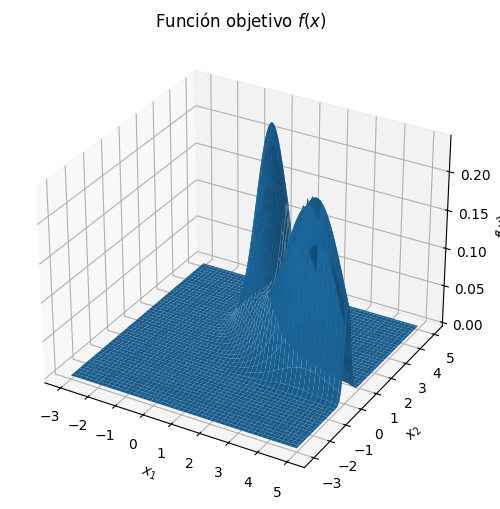

In [263]:
# Se impornta la libreria necesaria para gráficar
import matplotlib.pyplot as plt

# Valores de x1 y x2 para construir la malla
x1 = np.linspace (-3, 5, 100)
x2 = np.linspace(-3, 5, 100)

#se contruye la malla con los calores de x1 y 2
X1, X2= np.meshgrid(x1, x2)

# Se evalúa la función f(x) en cada punto de la malla
F = f([X1, X2])

# Se crea la gráfia de superficie
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, F)

#titulo y nombre de los ejes
ax.set_title('Función objetivo $f(x)$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x)$')

plt.show()


## <font color="#2E75B6"> Caminata aleatoria</font>

De acuerdo con el algoritmo de Metropolis-Hastings, dado el estado actual $x_t$, se genera un nuevo valor candidato $Y$ mediante la distribución propuesta $q(x,y)$

En este caso, la propuesta $q$ se elige **simétrica**, es decir,

$$
q(x,y)=q(y,x).
$$

Para generar el nuevo valor candidato se utilizara una **caminata aleatoria**, es decir se generan variables aleatorias normales independientes:

$$
Z_1,Z_2\sim N(0,1).
$$

Después se forma el vector

$$
Z=(Z_1,Z_2)
$$

y el nuevo valor propuesto se obtiene mediante

$$
Y=X_t+Z.
$$
De esta manera, el candidato $Y$ se obtiene realizando un desplazamiento aleatorio a apartir del estado actual $X_t$.


## <font color="#2E75B6">5. Estado incial y generar el candidato </font>

El primer paso del algoritmo consiste en inicializar la cadena en un estado.
$$X_1=(x_1, x_2)$$

y hacer $t=1$

Parea comenzar la simulación se tomará
$$
X_1=(0,0).
$$

A partir de este estado se generan $Z_1$ Y $Z_2$ de manera independiente con distribución normal estándar. Posteriormente se construye
$$
Z=(Z_1,Z_2)
$$

y se obtiene el candidato

$$
Y=X_t+Z.
$$


In [264]:
# Paso 1: Se inicializa la cadena en x1= (0,0)
X = np.array([0.0, 0.0])

#se inicia el contador en t=1
t = 1

# Paso 2: Se genera Z1 Y Z2 ~ N(0,1) independientemente
Z1= np.random.normal(0, 1)
Z2= np.random.normal(0, 1)

# Se forma el vector Z = (Z1, Z2)
Z = np.array([Z1, Z2])

#se genbera el candidato Y= Xt +Z
Y = X + Z

print("Estado actual X_t =", X)
print("Vector Z =", Z)
print("Candidato Y =", Y)


Estado actual X_t = [0. 0.]
Vector Z = [1.27822333 0.82937709]
Candidato Y = [1.27822333 0.82937709]
Estado actual X_t = [0. 0.]
Vector Z = [0.56943929 0.04490433]
Candidato Y = [0.56943929 0.04490433]
Estado actual X_t = [0. 0.]
Vector Z = [ 0.93673898 -0.38091978]
Candidato Y = [ 0.93673898 -0.38091978]


## <font color="#2E75B6"> Probabilidad de aceptación</font>

Una vez generado el candidato $Y$, se debe determinar la probabilidad con la que será aceptado.

La probabilidad de aceptación se define como:

$$
\alpha(x,y)=\min\{\rho(x,y),1\},
$$

donde

$$
\rho(x,y)=
\frac{f(y)q(y,x)}
     {f(x)q(x,y)}.
$$

Se utilizara una propuesta simétrica, por lo que:

$$
q(x,y)=q(y,x).
$$

Por esta razón, la expresión se reduce a

$$
\rho(x,y)=\frac{f(y)}{f(x)}.
$$

Por lo tanto, para la caminata aleatoria utilizada en este ejercicio,


$$
\boxed{
\alpha(x,y)=
\min\left\{
\frac{f(y)}{f(x)},1
\right\}.
}
$$

Así, $\alpha(x,y)$ determina la probabilidad con la que el candidato $Y$ será aceptado como el siguiente estado de la cadena.

In [265]:
# Se define la probabilidad de aceptación aplha(x,y)
def alpha(x,y):
  #como q(x,y) es simetrica, se utiliza f(y)/f(x)
  rho = f(y) / f(x)

  #alpha(x,y) = min{rho(x,y), 1}
  return min(rho, 1)

# se calcula alpha para el estado actual X y el candidato Y
a = alpha(X, Y)

print("Probabilidad de aceptación=", a)



Probabilidad de aceptación= 1
Probabilidad de aceptación= 1
Probabilidad de aceptación= 1


## <font color="#2E75B6">Regla de aceptación o rechazo</font>

Una vez calculada la probabilidad de aceptación $\alpha(X_t,Y)$, se genera una variable aleatoria

$$
U\sim U(0,1).
$$

De acuerdo con el algoritmo presentado en las notas de clase, el siguiente estado de la cadena se determina mediante

$$
X_{t+1}=
\begin{cases}
Y, & \text{si } U<\alpha(X_t,Y),\\[4pt]
X_t, & \text{otro caso}.
\end{cases}
$$

Por lo tanto, si $U$ es menor que la probabilidad de aceptación, el candidato $Y$ se acepta y se convierte en el siguiente estado de la cadena. En caso contrario, el candidato se rechaza y la cadena permanece en el estado actual $X_t$.

In [266]:
# Paso 3. Se genera U ~ U(0,1)
U = np.random.uniform(0, 1)

# Se aplica la regla de aceptación o rechazo
if U < a:
    X_nueva = Y
else:
    X_nueva = X

print("U =", U)
print("alpha =", a)
print("Siguiente estado =", X_nueva)

U = 0.23233059331969863
alpha = 1
Siguiente estado = [0.56943929 0.04490433]
U = 0.9895677232961259
alpha = 1
Siguiente estado = [ 0.93673898 -0.38091978]


## <font color="#2E75B6">Implementación del algoritmo de Metropolis</font>

Para obtener una muestra completa, los pasos anteriores se repiten hasta alcanzar el tamaño de muestra $N$.

El procedimiento utilizado es el siguiente:

1. Inicializar $X_1=(x_1,x_2)$ y hacer $t=1$.
2. Generar $Z_1,Z_2\sim N(0,1)$ independientemente, formar $Z=(Z_1,Z_2)$ y obtener

$$
Y=X_t+Z.
$$

3. Calcular

$$
\alpha(X_t,Y)=
\min\left\{
\frac{f(Y)}{f(X_t)},1
\right\}.
$$

4. Generar $U\sim U(0,1)$ y tomar

$$
X_{t+1}=
\begin{cases}
Y, & \text{si } U<\alpha(X_t,Y),\\[4pt]
X_t, & \text{otro caso}.
\end{cases}
$$

5. Hacer $t=t+1$. Si se alcanza el tamaño de muestra $N$, el algoritmo se detiene; en otro caso, se repite el procedimiento.

Para realizar la simulación de utlizará
$$
N=10000.
$$



In [267]:
# Tamaño de la muestra
N= 10000

#Lista vacia para guardar los estados de la cadena
muestra = []


# Lista para guardar los estados de la cadena
muestra = []

# Paso 1: Inicializar x1= (0,0) y hacer t=1
X = np.array([0.0, 0.0])
t = 1

# Se guarda el estado inicial
muestra.append(X.copy())

#Se repite el procedimiento hasta obtener N estados
while t < N:

  # Paso 2: Generar Z1, Z2 ~ N(0,1) independientemente
  Z1 = np.random.normal(0,1)
  Z2 = np.random.normal(0,1)

  #Formar Z= (Z1, Z2)
  Z= np.array([Z1, Z2])

  #Generar el candidato Y = Xt + Z
  Y = X + Z

  #candidato alpha (Xt,Y)
  a=alpha (X,Y)

  #Paso 3: Generar U~ U(0,1)
  U=np.random.uniform(0,1)

  #Regla de aceptación o rechazo
  if U < a:
    X=Y
  else:
    X=X

  #Guardar el nuevo estado de la cadena
  muestra.append(X.copy())

  #Paso 4: Hacer t= t+1
  t = t+1

#Convertir la muestra en un arreglo de Numpy
muestra = np.array(muestra)
print("Tamaño de la muestra:", len(muestra))
print("Primeros estados generados:")
print(muestra[:5])


Tamaño de la muestra: 10000
Primeros estados generados:
[[ 0.          0.        ]
 [ 0.          0.        ]
 [ 1.18569056 -0.57478331]
 [ 1.18569056 -0.57478331]
 [ 1.18569056 -0.57478331]]
Tamaño de la muestra: 10000
Primeros estados generados:
[[ 0.          0.        ]
 [ 1.61780241 -0.41925626]
 [ 1.61780241 -0.41925626]
 [ 1.77466257  1.80985366]
 [ 1.47373193  2.40770898]]


## <font color="#2E75B6"> Representación de la muestra obtenida</font>

Una vez ejecutado el algoritmo de Metropolis, se obtiene una muestra formada por los estados

$$
X_t=(X_{1,t},X_{2,t}), \qquad t=1,\ldots,N.
$$

Para observar la distribución se loos valores generados se realiza una gráfica de dispersión, colocando la primera componente $X_1$ en ele eje horizontal y la segunda componente $X_2$ en ele eje vertical.

Eso permitirá observar las regiones del plano en las que se concentra la muestra generada por la cadena de Markov.


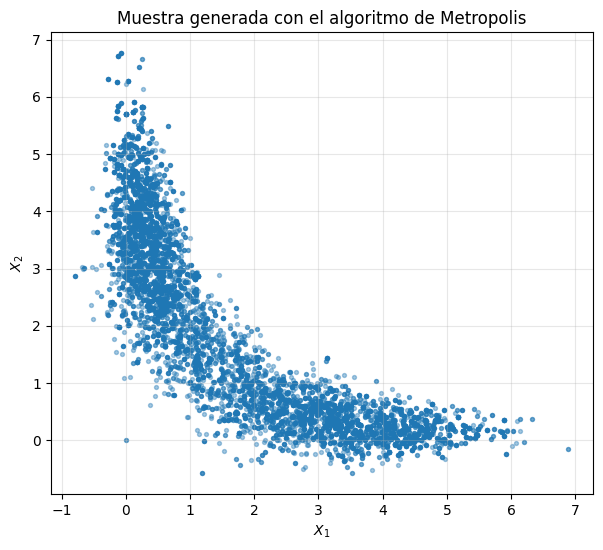

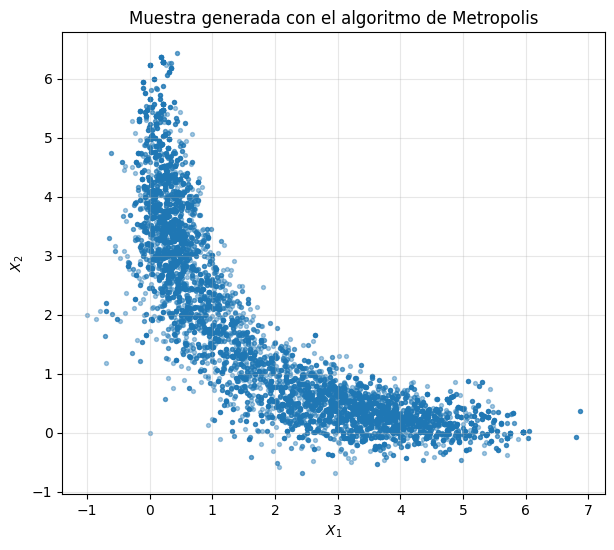

In [268]:
#se separan las dos componentes de la muestra
X1= muestra[:,0]
X2= muestra[:,1]

#Gráfica de dispersión de la muestra obtenida
plt.figure(figsize=(7, 6))
plt.scatter(X1, X2, s=8, alpha=0.4)
plt.title('Muestra generada con el algoritmo de Metropolis')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(alpha=0.3)

plt.show()

### <font color="#2E75B6">Observación</font>
En la gráfica se observa que los puntos se concentran en una región específica y forman una trayectoria curva. Además, cuando $X_1$ aumenta, $X_2$ tiende a disminuir. Esto muestra cómo se distribuyen los valores generados por el algoritmo de Metropolis de acuerdo con la función objetivo $f(x)$.

## <font color="#2E75B6">Comportamiento de la cadena</font>

También se puede observar como cambian las componentes $X_1$ y $X_2$ conforme avanza la simulación.
Para ello se representaran los valores generados en cada iteración $t$. Estas gráficas perrmiten visualizar el recorrido de las dos componentes de la cadena durante las $N$ iteraciones del algoritmo.



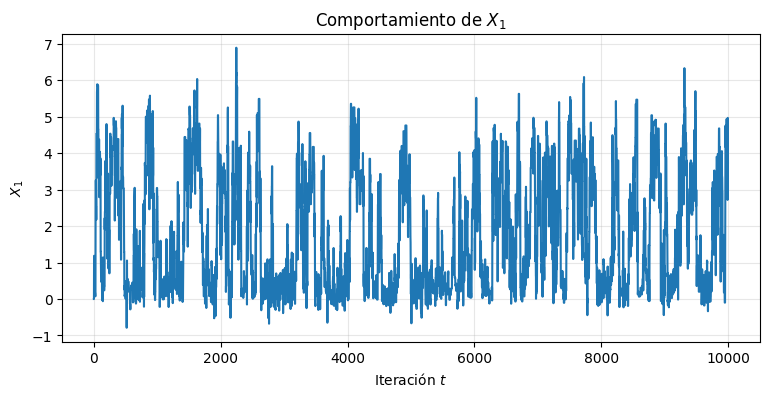

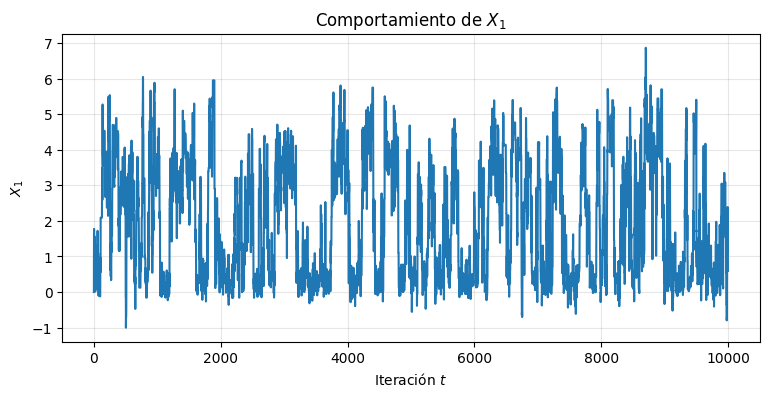

In [269]:
# Gráfica de los valores generados de X1
plt.figure (figsize=(9,4))
plt.plot (X1)

plt.title('Comportamiento de $X_1$')
plt.xlabel('Iteración $t$')
plt.ylabel('$X_1$')
plt.grid(alpha=0.3)

plt.show()


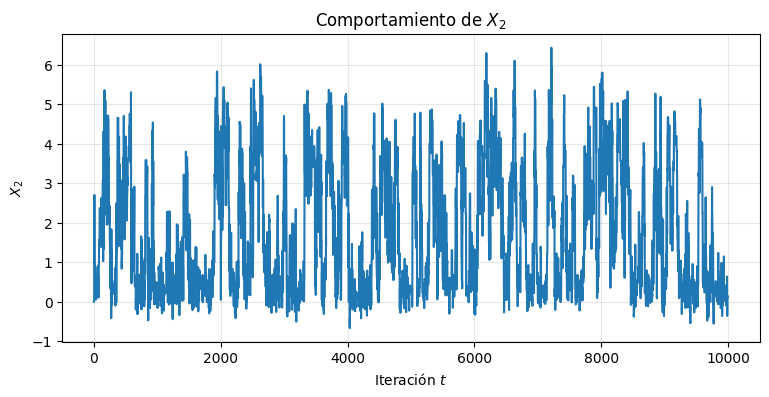

In [253]:
# Gráfica de los valores generados de X2
plt.figure(figsize=(9, 4))

plt.plot(X2)

plt.title('Comportamiento de $X_2$')
plt.xlabel('Iteración $t$')
plt.ylabel('$X_2$')
plt.grid(alpha=0.3)

plt.show()


### <font color="#2E75B6">Observación</font>
En ambas gráficas se observa que los valores de $X_1$ y $x_2$ van cambiando a lo largo de las iteraciones. En algunos momentos la cadena permanece en valores similares y después se desplaza a otros, debido al proceso de aceptación o rechazo del algoritmo de Metropolis.

Esto muestra el recorrido de las dos componentes de la cadena durante las $N=10000$ iteraciones.

## <font color="#2E75B6">Conclusión</font>

Se implementó el algoritmo de Metropolis para generar una muetsra del vector $X=(X_1,X_2)$ a partir de la fucnión objetivo $f(x)$.
Para generar cada candidato se utilizó una caminata aleatoria de la forma:

$$
Y=X_t+Z,
$$

donde

$$
Z=(Z_1,Z_2), \qquad Z_1,Z_2\sim N(0,1)
$$

de manera independiente.
Debido a que la propuesta utilizada es simétrica, la probabilidad de aceptación se simplificó a

$$
\alpha(X_t,Y)
=
\min\left\{
\frac{f(Y)}{f(X_t)},1
\right\}.
$$

En cada iteración se generó $U\sim U(0,1)$ y se comparó con $\alpha(X_t,Y)$. Si $U<\alpha(X_t,Y)$, el candidato $Y$ se aceptó como el siguiente estado; en otro caso, la cadena permaneció en $X_t$.

Finalmente, los estados generados se almacenaron y representaron gráficamente para observar la muestra obtenida y el comportamiento de las componentes $X_1$ y $X_2$ durante la simulación.